---
title: "Modeling a Coin Flip Game"
author: "Josh Pearlson"
date: "2024-08-16"
categories: [Python, Probability]
css: style.css
---

A casino offers a game: Flip a coin as long as you want. Your prize is the ratio of heads to total flips. What's your strategy to maximize your winnings?

## Coin Flip Game

Imagine you're in a casino. Instead of slot machines or table games, a dealer offers you a coin game and explains the rules: 

> I will pay you based on the outcome of a coin flip game. You can flip the coin as **many times as you want**, and you can **stop whenever you like**. I will pay you based on the ratio of heads to total flips. I will **charge you 75 cents to play** and **pay you one dollar multiplied by your heads-to-total-flips ratio**. Would you like to play? 

At first glance it appears the casino is offering us a losing wager (as is typical). In any long-run scenario you would expect to get a ratio of 1/2 heads to total flips, since heads and tails are equally likely to occur on any given flip. In that case, we would be paying 75 cents to play a game where we would only be getting paid 50 (1 heads for every 1 tails) cents! That calculation assumes we keep flipping. We can also choose to stop, so we need to account for that choice.

##  Basic Strategy

First, let's review the problem: We have a fair coin (50% heads, 50% tails) and we can flip it as many times as we want. Our goal is to maximize the ratio of heads to total flips.

First, we should think about a simplified case to get a better understanding of the game dynamics. We will create a decision tree to visualize our options following the outcome of the first flip:

``` 
Start Game
     |
     +-- Flip 1: Heads (50% chance)
     |     |
     |     +-- Ratio is 1.0 (1 head / 1 flip)
     |     +-- DECISION: STOP. This is the best possible ratio.
     |     +-- OUTCOME: Profit (1.0 payout > 0.75 cost)
     |
     +-- Flip 1: Tails (50% chance)
           |
           +-- Ratio is 0.0 (0 heads / 1 flip)
           +-- DECISION: CONTINUE. Stopping means a 0.0 payout.
                 |
                 +-- Keep flipping...
                 +-- Long-run ratio approaches 0.5
                 +-- OUTCOME: Loss (0.5 payout < 0.75 cost)
```
When we flip heads on the first flip we win the game outright with the best possible payout ratio of 1.0 heads/total flips (giving us the game's maximum profit of 100 (payout) - 75 (cost) = 25 cents). However if we flip tails on the first flip we are in a losing situation where we will have to continue flipping, for now, consider stopping at a fixed, very large number of flips after an initial tail. The expected ratio then approaches 0.5 from below as that cutoff grows. A limiting ratio is not itself a finite stopping time.

In the limit, half the games pay a profit of 25 cents immediately, and the other half have an expected loss approaching 25 cents. Finite cutoffs can approach a break-even expected value arbitrarily closely. Thus the supremum of expected profit over stopping rules satisfies:

<div style="text-align: left;">
$$
\begin{aligned}
 \sup EV_{game} &\geq  \\ 
 &\frac{1}{2} (1.0 - 0.75) + 
 \frac{1}{2} (0.5 - 0.75)  \\
 &= \frac{1}{2} (0.25) +
\frac{1}{2} (-0.25) \\
 &= \$0 
\end{aligned}
$$
</div>

If we wish to improve on this strategy we need to consider a new approach. What if we consider stopping at the first time that we see we have flipped heads more often than tails? 

### Stop When Heads > Tails Strategy 

I will create a table with the first couple of possible stopping points (locations where # heads > # tails) for this game: 

| Flip Sequence | Heads | Tails | Ratio (Heads/Total Flips) | Probability of sequence| 
|---------------|-------|-------|----------------------------|-------------------------|
| H             | 1     | 0     | 1.0                        | 1/2                    |
| T H H         | 2     | 1     | 0.67                       | 1/2 ^3                  |
| T T H H H     | 3     | 2     | 0.60                       | 1/2 ^5                  |
| T H T H H     | 3     | 2     | 0.60                       | 1/2 ^5                  |

From the table above we can see that if we stop at the first time we have more heads than tails we can achieve a ratio of 1.0, .67, .60, etc. Each stopping point is less and less likely, there is $\frac{1}{2}^{\text{\# total flips}}$ chance of achieving each outcome. However, we can see that the ratios we achieve are all greater than 0.5 heads/total flips. Another thing we notice is that the longer sequences clearly have many more paths (at much lower likelihoods) than the shorter sequences.

Let's plot the possible outcomes of this game to count the number of paths that lead to each outcome:


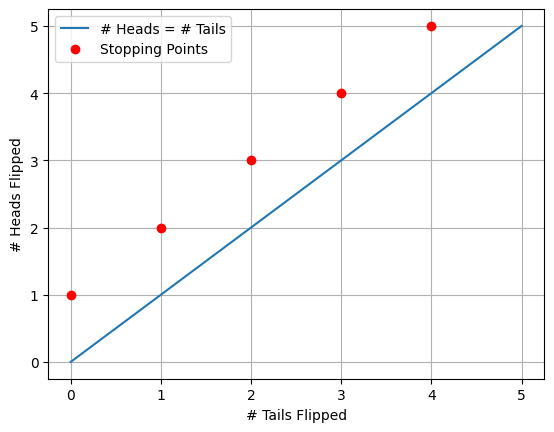

In [1]:
#| echo: false

import matplotlib.pyplot as plt

list = [i for i in range(6)]
plt.plot(list,list, label= '# Heads = # Tails')
plt.xlabel('# Tails Flipped')
plt.ylabel("# Heads Flipped")

plt.plot(0, 1, 'o', label='Stopping Points', color='red')
plt.plot(1, 2, 'o', color='red')
plt.plot(2, 3, 'o', color='red')
plt.plot(3, 4, 'o', color='red')
plt.plot(4, 5, 'o', color='red')

plt.grid()

plt.xticks(list)
plt.yticks(list)

plt.legend()
plt.show()

As we can see above, we have the blue line showing the threshold where the number of heads and tails flipped are equal. The red dots are showing us our stopping points, where we have flipped more heads than tails for the first time. Only valid paths from (0,0) to each red dot without crossing the blue line are possible outcomes of the strategy! We also know that each time we flip a coin N times our chance of getting one exact path is 1/2^N. Given this graphical representation we can now use combinatorics to count the number of paths that lead to each stopping point and multiply this by our probability of getting to that same path. 

For some arbitrary number k, we will stop when we have flipped k+1 heads and k tails. The total number of flips will be 2k+1 and our heads/total flips ratio will be (k+1)/(2k+1). 

The EV of this game can be calculated as the sum of each stopping-point ratio multiplied by the probability of reaching that ratio minus the cost to play (75 cents). 

<div style="text-align: left;">
$$
\begin{aligned}
EV_{game} &= \sum_{k=0}^{\infty} \left( \frac{\text{Heads}}{\text{Total Flips}} \cdot P(k) \right) - 0.75 \\
EV_{game} &= \sum_{k=0}^{\infty} \left( \frac{k+1}{2k+1} \cdot P(k) \right) - 0.75 \\
\end{aligned}
$$
</div>

How do we calculate P(k)? We can count paths in the diagram above. Here we can see that there are a number of paths that lead to each stopping point. However not all paths are valid, since some paths cross the blue line (where heads = tails) before reaching the stopping point. To calculate the number of valid paths to each stopping point we can use the ballot theorem from combinatorics.

> The [ballot theorem](https://en.wikipedia.org/wiki/Bertrand%27s_ballot_theorem) states that if in an election candidate A receives h votes and candidate B receives k votes with h>k, then the number of ways the votes can be counted such that A is always strictly ahead of B is given by:

<div style="text-align: left;">
$$
\begin{aligned}
\frac{h-k}{h+k} \binom{h+k}{k} \\
\end{aligned}
$$
</div>

A special case of this theorem is when h = k + 1, exceeding votes by exactly one. To connect this to our stopping rule, reverse a valid flip sequence. A path that first reaches a heads surplus of one on its final flip becomes a reversed path with heads strictly ahead at every step. This gives a one-to-one correspondence with the ballot theorem’s paths. Let's now solve for this special case:

<div style="text-align: left;">
$$
\begin{aligned}
% & \frac{h-k}{h+k} \binom{h+k}{k} \\
& h = k + 1 \\
& \text{Substituting h for its new value of k + 1}  \\
& = \frac{(k+1)-k}{(k+1)+k} \binom{(k+1)+k}{k} \\
& = \frac{1}{2k+1} \binom{2k+1}{k} \\
& = \frac{1}{2k+1} \cdot \frac{(2k+1)!}{(k+1)! k!} \\
& (2k+1)! = (2k+1)((2k)!) \\
& = \frac{1}{2k+1} \cdot \frac{(2k+1)((2k)!)}{(k+1)! k!} \\
& = \frac{(2k)!}{(k+1)! k!} \\
& (k+1)! = (k+1)(k!) \\
& = \frac{(2k)!}{(k+1)(k!) k!} \\
& = \frac{1}{k+1} \cdot \frac{(2k)!}{k! k!} \\
& = \frac{1}{k+1} \binom{2k}{k} \\
\end{aligned}
$$
</div>

The sequence we have arrived at above is the sequence in combinatorics called the [Catalan numbers](https://en.wikipedia.org/wiki/Catalan_number). Catalan numbers have many applications in combinatorial mathematics including counting valid parentheses expressions, counting rooted binary trees, and **counting paths in a grid that do not cross a diagonal line**. In our case we are using them to count the number of valid paths to each stopping point in our coin flip game. The number of paths to the k-th number stopping point (where num heads = k + 1 and num tails = k) happens to be the k-th Catalan number! 

Let's calculate the expected value of the stop when heads exceeds tails by one strategy.

### Calculating EV of Stop When Heads > Tails

Strategy: Let each stopping point k be defined as the first time # heads = k + 1 and # tails = k. In this game we are paid out based on the number of heads / total flips ratio at some stopping point k. As defined previously the value at the k-th stopping is (k + 1) / (2k + 1). The probability of reaching this stopping point is equal to the number of valid paths to this stopping point (equivalent to the kth Catalan number) multiplied by the probability of reaching any one path (1/2^(total flips) = (1/2 ^ (2k+1)). We also know that the EV of the game is equal to the payout minus the cost to play the game (75 cents). First let's calculate the expected payout (EP) of this strategy: 

<div style="text-align: left;">
$$
\begin{aligned}
EP_{strategy} &= \sum_{k=0}^{\infty} \left( \frac{\text{Heads}}{\text{Total Flips}} \cdot P(k) \right) \\
EP_{strategy} &= \sum_{k=0}^{\infty} \left( \frac{k+1}{2k+1} \cdot P(k) \right) \\
P(k) &= C_k \cdot \left( \frac{1}{2} \right)^{2k+1} \\
EP_{strategy} &= \sum_{k=0}^{\infty} \left( \frac{k+1}{2k+1} \cdot C_k \cdot \left( \frac{1}{2} \right)^{2k+1} \right) \\
EP_{strategy} &= \sum_{k=0}^{\infty} \left( \frac{k+1}{2k+1} \cdot \frac{1}{k+1} \binom{2k}{k} \cdot \left( \frac{1}{2} \right)^{2k+1} \right) \\
EP_{strategy} &= \sum_{k=0}^{\infty} \left( \frac{1}{2k+1} \cdot \binom{2k}{k} \cdot \left( \frac{1}{2} \right)^{2k+1} \right) \\   
EP_{strategy} &= \sum_{k=0}^{\infty} \left( \frac{1}{2k+1} \cdot \frac{(2k)!}{(k!)^2} \cdot \left( \frac{1}{2} \right)^{2k+1} \right) \\
&\text{After further simplification we arrive at:} \\
EP_{strategy} &= \frac{1}{2} * \sum_{k=0}^{\infty} \left( \frac{\binom{2k}{k}}{4^k (2k+1)} \right) \\
\end{aligned}
$$
</div>

Here we use the fact that the sum above is equal to the Taylor series expansion of arcsin(x) evaluated at x = 1. The result is as follows: 

<div style="text-align: left;">
$$
\begin{aligned}
\arcsin(x) &= \sum_{k=0}^{\infty} \left( \frac{\binom{2k}{k}}{4^k (2k+1)} x^{2k+1} \right) \\
\arcsin(1) &= \sum_{k=0}^{\infty} \left( \frac{\binom{2k}{k}}{4^k (2k+1)}  \right) \\
\arcsin(1) &= \frac{\pi}{2} \\
\frac{\pi}{2} &= \sum_{k=0}^{\infty} \left( \frac{\binom{2k}{k}}{4^k (2k+1)} \right)\\
EP_{strategy} &= \frac{1}{2} * \frac{\pi}{2} = \frac{\pi}{4} \approx 0.7854 \\ 
EV_{strategy} &= EP_{strategy} - \text{Cost to Play} \\
EV_{strategy} &= \frac{\pi}{4} - 0.75 \approx 0.0354 \\
\end{aligned}
$$
</div>


This strategy has a positive expected profit. By stopping the first time heads exceeds tails, we get an expected profit of about 3.54 cents per game. This stopping time is finite with probability one, but its expected number of flips is infinite. A positive expected profit per game therefore does not imply a useful hourly return. This would be a ROI of about 4.72% on each 75 cent wager!


## Strategy Improvement 

The 'stop when heads > tails' strategy clearly works, however, it seems like there could be a better strategy. What if we only accept a heads/total flips ratio of greater than 0.51, or 0.55, or 0.60? Could we do even better?

In this exploration two things interest me most:

1. What is the optimal policy for the 'stop when heads/total flips > X' strategy?
2. Is there a better policy that could outperform stop when 'heads/total flips > X'?

First, let's evaluate a threshold strategy with a **50-cent fallback**. Flips are independent and fair, and there is no time limit or cost per flip:

1. Stop if heads/total flips exceeds the chosen threshold during the first $N$ flips.
2. If the threshold has not been reached by $N$, collect the current ratio if it is at least one half.
3. Otherwise, keep flipping until heads and tails are equal, then collect 50 cents.

The law of large numbers says the heads ratio converges to one half with probability one. To justify collecting exactly 50 cents at a finite stopping time, we use another fact: a [symmetric random walk is recurrent](https://math.dartmouth.edu/~doyle/docs/walks/walks.pdf). Starting from any finite deficit, heads eventually catches up with tails with probability one. The waiting time is finite almost surely, but its expectation is infinite.

That makes $\max(0.5,h/N)$ a valid fallback payout after $N$ flips with $h$ heads. Below one half, this represents continuing to a tie, not collecting money before earning it. The calculation can account for that eventual payout without simulating the extra flips. Here $N$ ends the threshold phase; it is **not a limit on the game's total flips**.

This is a specific two-stage strategy. It differs from continuing to chase the original threshold forever. I will evaluate it by propagating the probability of each possible heads count, avoiding sampling noise.

### Python Calculation for 'Stop When Heads/Total Flips > X' {#python-simulation-for-stop-when-headstotal-flips-x-strategy}

For each live state after $n$ flips, half its probability goes to the same heads count after a tail, and half goes to one additional head. When a state stops, add its probability times its payout to the total and remove it from future flips. This sums over paths without storing each path separately. The calculation is deterministic, with ordinary floating-point rounding.


In [2]:
#| echo: false
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
def evaluate_threshold(threshold_percent: int, switch_after: int):
    """Follow a threshold, then collect at least half by waiting for a tie if needed."""
    if not 0 <= threshold_percent <= 100 or switch_after < 1:
        raise ValueError("Use a threshold from 0 to 100 and a positive number of threshold-phase flips.")
    live = np.array([1.0])
    expected_payout = 0.0
    fallback_probability = 0.0

    for n in range(1, switch_after + 1):
        following = np.zeros(n + 1)
        following[:-1] += 0.5 * live  # Tail: heads count stays the same.
        following[1:] += 0.5 * live   # Head: heads count increases by one.
        heads = np.arange(n + 1)
        # Integer comparison avoids rounding at exact threshold ties.
        stop = 100 * heads > threshold_percent * n
        payouts = heads / n
        if n == switch_after:
            fallback_probability = float(following[~stop].sum())
            # Below half, continue past switch_after until heads and tails tie.
            # Recurrence gives an eventual payout of exactly 0.5, almost surely.
            payouts[~stop] = np.maximum(0.5, payouts[~stop])
            stop = np.ones(n + 1, dtype=bool)
        expected_payout += float(np.dot(following[stop], payouts[stop]))
        following[stop] = 0.0
        live = following

    return expected_payout, fallback_probability


switch_points = (100, 1000, 5000)
results = []
for switch_after in switch_points:
    for threshold_percent in range(50, 65):
        payout, fallback_probability = evaluate_threshold(threshold_percent, switch_after)
        results.append({
            "Threshold-phase flips": switch_after,
            "Stop ratio": threshold_percent / 100,
            "Expected payout": payout,
            "Expected profit": payout - 0.75,
            "Fallback probability": fallback_probability,
        })

df_all_results = pd.DataFrame(results)


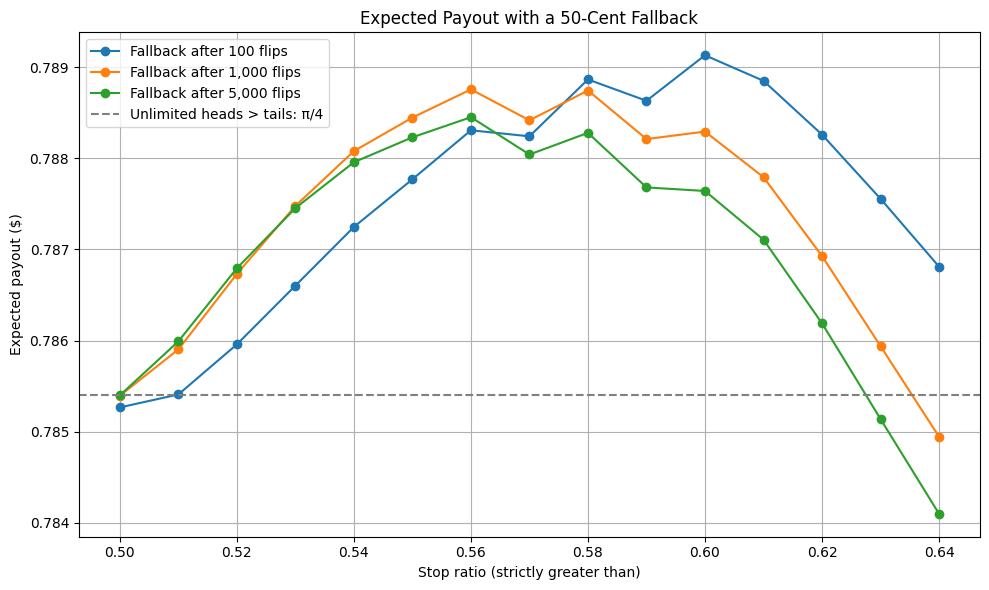

In [4]:
#| echo: false
fig, ax = plt.subplots(figsize=(10, 6))
for switch_after, group in df_all_results.groupby("Threshold-phase flips"):
    ax.plot(group["Stop ratio"], group["Expected payout"], marker="o",
            label=f"Fallback after {switch_after:,} flips")
ax.axhline(np.pi / 4, color="gray", linestyle="--", label="Unlimited heads > tails: π/4")
ax.set(title="Expected Payout with a 50-Cent Fallback",
       xlabel="Stop ratio (strictly greater than)", ylabel="Expected payout ($)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


In [5]:
#| echo: false
(df_all_results[df_all_results["Threshold-phase flips"] == 1000]
 .drop(columns="Threshold-phase flips").set_index("Stop ratio").round(6))


,Expected payout,Expected profit,Fallback probability
Stop ratio,,,
0.50,0.785394,0.035394,0.025225
0.51,0.785902,0.035902,0.042522
0.52,0.786731,0.036731,0.066234
0.53,0.787478,0.037478,0.091053
0.54,0.788079,0.038079,0.115600
0.55,0.788447,0.038447,0.139108
0.56,0.788757,0.038757,0.161203
0.57,0.788417,0.038417,0.176643
0.58,0.788744,0.038744,0.201132


With the fallback starting after 1,000 flips, the 0.50 threshold pays about $0.785394$ dollars on average, close to the $\pi/4 \approx 0.785398$ payout from waiting until heads first exceeds tails. The values differ because the fallback can stop at a tie, whereas the original rule waits for a heads surplus.

Among the thresholds tested, 0.56 gives the highest expected payout with this switch point: approximately $0.788757$, or **3.88 cents of expected profit** on the 75-cent entry fee. About **16.12%** of games reach the fallback stage without crossing the threshold. Some can collect immediately; those below one half continue until a tie.

The plot also compares fallback switch points of 100 and 5,000 flips. Keeping a fixed threshold for longer does not necessarily improve its expected payout. These results compare the stated two-stage strategies, not all possible stopping rules.

### Could a Different Stopping Rule Do Better? {#the-most-optimal-policy}

Yes. A fixed ratio ignores how many flips have occurred. Let $V_N(h,n)$ be the best expected payout after $n$ flips, of which $h$ were heads, when we can choose when to stop before switching to the same fallback at $N$. The fallback value is:

$$V_N(h,N)=\max\left(\frac{h}{N},\frac{1}{2}\right).$$

Before then, compare stopping now with the expected value of one more flip:

$$V_N(h,n)=\max\left(\frac{h}{n},\;\frac{V_N(h+1,n+1)+V_N(h,n+1)}{2}\right),\qquad 1\leq n<N.$$

Working backward through these states finds the optimal policy within this class, where the fallback takes over at $N$. It does not optimize decisions after that point; the fallback rule is fixed. The entry fee is already paid, so it does not affect the stop-or-continue comparison. The unlimited-time version is the [Chow–Robbins game](https://arxiv.org/abs/1201.0626), which requires more care than choosing a single ratio.

What about waiting for an almost-all-heads result? That brings us to the infinite monkey theorem.

![Infinite Monkey Theorem](../../../media/Chimpanzee_seated_at_typewriter.jpg)

An endless sequence of independent fair coin flips contains every particular finite pattern with probability one. But a long run of heads somewhere in the sequence does not erase the tails that came before it. Our payout uses **all flips since the start**, not a favorable stretch we select afterward.

For example, after an initial tail the cumulative ratio can never equal one at any finite stopping time. More generally, the cumulative heads ratio converges to one half with probability one. The infinite monkey theorem therefore does not guarantee an eventual near-100% payout. Allowing more time can improve a stopping strategy, but it does not justify the claimed 25-cent guaranteed profit.


## Findings

The option to stop changes this game's expected payout. A player can choose when to collect their winnings instead of accepting the long-run heads ratio and its 50-cent payout.

### Analytical Solution

Stopping the first time heads exceeds tails gives an expected payout of π/4 ≈ 0.7854. We derived this using Catalan numbers to count the paths to each stopping point. With a cost of 0.75, the expected profit is approximately 3.54 cents per game.

### Numerical Results

Probability propagation evaluates fixed thresholds followed by a 50-cent fallback. With the fallback starting after 1,000 flips, the best threshold tested is 0.56, with an expected payout of approximately $0.788757$ and expected profit of 3.88 cents. Games below one half at that point continue until a tie. This is the value of the stated strategy, not the optimal value of the unlimited game.

### The Value of Optionality

The long-run probability of heads is 50%, but the player can stop when the observed heads ratio is higher. The stopping rule determines how much that choice is worth.

## Future Work

The numerical comparison above uses a fixed ratio as the stopping threshold. There are several ways to extend this analysis.

### Dynamic Stopping Policy

The backward recursion above uses both the number of heads and the total number of flips. Implementing it would let us compare a state-dependent policy with the fixed thresholds. A 52% ratio after 1,000 flips changes less after another flip than a 52% ratio after only 25 flips. The decision is whether the expected benefit of continuing exceeds the payout available now.

### Analysis with a Biased Coin

A biased coin (where P(Heads) ≠ 0.5) would require recalculating the expected values and would likely change the optimal stopping thresholds.

### Risk-Adjusted Strategies

This analysis focuses on expected value. A player might instead care about the probability of breaking even or avoiding a large loss. Utility theory could help compare strategies for those preferences.

### Different Payout Structures

How would the strategy change if the casino changed its payout function? We could examine non-linear payouts (e.g., (heads/total_flips)^2) or different entry costs to see how the stopping rule changes.

---
These are just some initial thoughts by me and I am open to discussion. As always, feel free to reach out to [me](mailto:jcp@joshpearlson.com) for suggestions on future articles or comments.
